In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error , r2_score

In [3]:
from sklearn.datasets import load_diabetes

df = load_diabetes()

x = df.data
y = df.target

In [8]:
x.shape

(442, 10)

In [4]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [9]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train , y_train)

LinearRegression()

In [11]:
y_pred = lr.predict(x_test)

print("MSE : " , mean_squared_error(y_test , y_pred))
print("R2 Score : " , r2_score(y_test , y_pred))

MSE :  3094.4566715660626
R2 Score :  0.4399338661568968


# **Applying Ridge Regularization**

In [18]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.1)

In [19]:
ridge.fit(x_train , y_train)

y_pred = ridge.predict(x_test)

print("MSE : " , mean_squared_error(y_test , y_pred))
print("R2 Score : " , r2_score(y_test , y_pred))

MSE :  3027.817261919799
R2 Score :  0.45199494197195456


In [21]:
print(ridge.coef_)
print(ridge.intercept_)

[   6.64373321 -172.23747375  485.52958514  314.67584612  -72.94020918
  -80.58868817 -174.46352722   83.61470987  484.36531622   73.58509056]
151.92546856900984


**Visualization of Ridge with the help of Polynomial Regression**

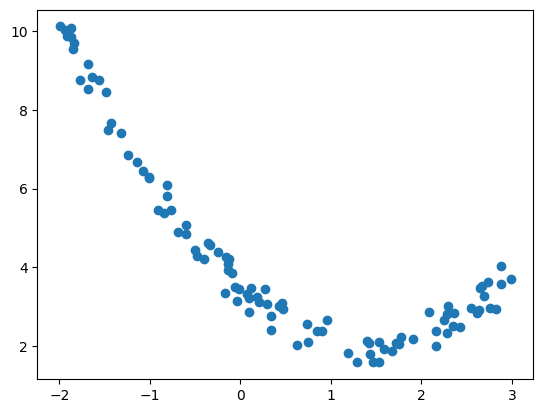

In [22]:
# Creating synthetic data
x = 5 * np.random.rand(100,1) - 2
y = 0.7*(x**2) - 2*x + 3 + np.random.rand(100, 1)

plt.scatter(x , y)
plt.show()

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1 , x2 , alpha):
  model = Pipeline([
   ('poly' , PolynomialFeatures(degree=16)),
   ('ridge' , Ridge(alpha=alpha))
  ])

  model.fit(x1 , x2)
  return model.predict(x1)

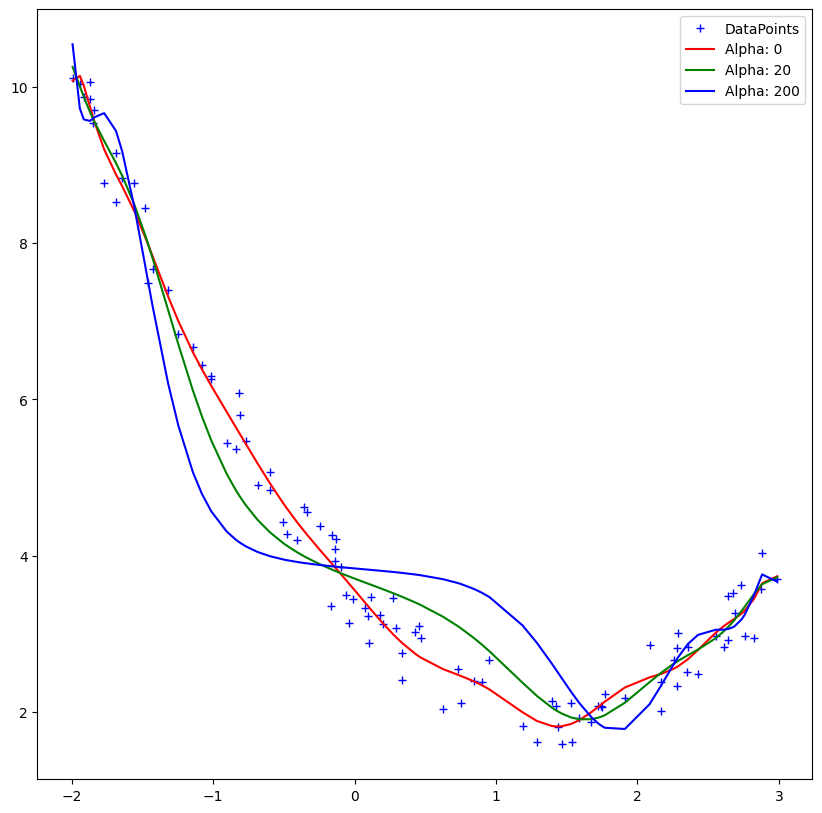

In [27]:
alphas = [0 , 20 ,200]
cs = ['r','g','b']

plt.figure(figsize=(10,10))
plt.plot(x , y , 'b+' , label='DataPoints')

for alpha , c in zip(alphas , cs):
  preds = get_preds_ridge(x , y , alpha)

  plt.plot(sorted(x[:, 0]), preds[np.argsort(x[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()